# 📘 CIFAR-10 Image Classification — ANN vs CNN
### Week 4 Assignment | Deep Learning | Celebal Technologies

---

## 🎯 Objective
Build and compare image classification models on **CIFAR-10** using:
- **ANN (Artificial Neural Network)** — treats images as flat vectors
- **CNN (Convolutional Neural Network)** — extracts spatial features via convolutions

Analyze performance across:
- Accuracy & loss curves
- Generalization (train vs val gap)
- Training strategies: Dropout, Batch Normalization, Data Augmentation, EarlyStopping

---

## 📦 CIFAR-10 Dataset
| Property | Value |
|----------|-------|
| Total Images | 60,000 |
| Training | 50,000 |
| Test | 10,000 |
| Image Size | 32×32×3 (RGB) |
| Classes | 10 |

**Classes:** ✈️ Airplane, 🚗 Automobile, 🐦 Bird, 🐱 Cat, 🦌 Deer, 🐶 Dog, 🐸 Frog, 🐴 Horse, 🚢 Ship, 🚛 Truck

---
## ⚙️ Step 1 — Setup & Imports

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {tf.keras.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available     : {len(gpus)}')

TensorFlow version : 2.20.0
Keras version      : 3.13.2
GPUs available     : 0


---
## 📥 Step 2 — Load CIFAR-10 Dataset

CIFAR-10 has **50,000 training** and **10,000 test** colour images of size **32×32×3**.

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

print(f'x_train shape : {x_train.shape}  | dtype: {x_train.dtype}')
print(f'y_train shape : {y_train.shape}')
print(f'x_test  shape : {x_test.shape}')
print(f'y_test  shape : {y_test.shape}')
print(f'Pixel range   : [{x_train.min()}, {x_train.max()}]')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
x_train shape : (50000, 32, 32, 3)  | dtype: uint8
y_train shape : (50000, 1)
x_test  shape : (10000, 32, 32, 3)
y_test  shape : (10000, 1)
Pixel range   : [0, 255]


---
## 🖼️ Step 3 — Visualise Sample Images

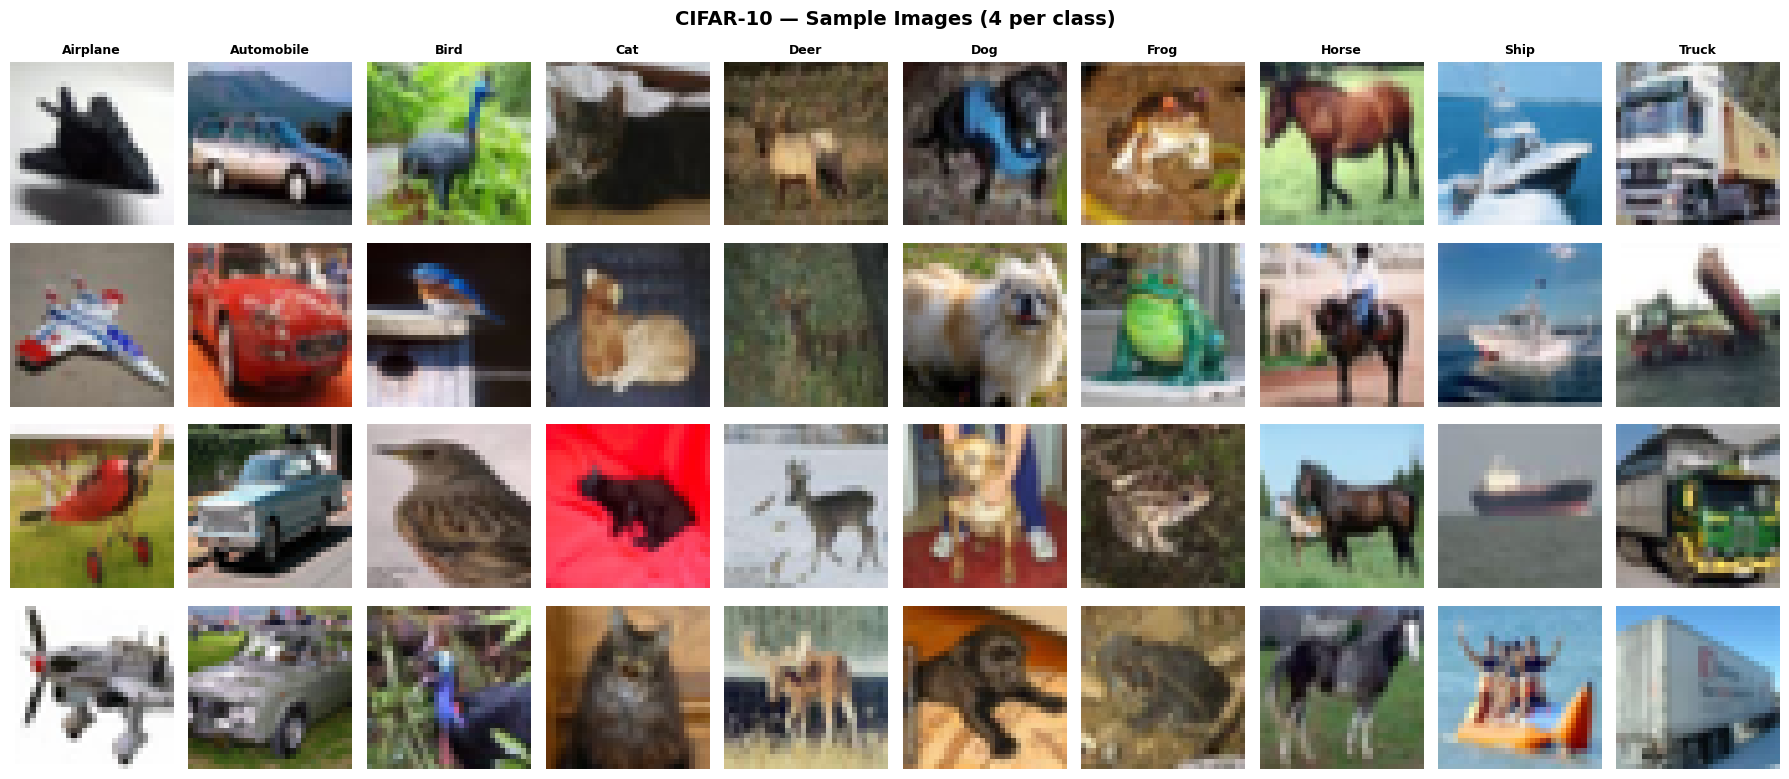

In [ ]:
fig, axes = plt.subplots(4, 10, figsize=(18, 8))
fig.suptitle('CIFAR-10 — Sample Images (4 per class)', fontsize=14, fontweight='bold')

for col, cls_name in enumerate(class_names):
    idx = np.where(y_train.flatten() == col)[0][:4]
    for row, i in enumerate(idx):
        axes[row, col].imshow(x_train[i])
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(cls_name, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 🧹 Step 4 — Preprocessing

| Step | Description |
|------|-------------|
| Normalise | Scale pixels 0–255 → 0.0–1.0 (stabilises gradients) |
| Flatten | Reshape 32×32×3 → 3072 (required for ANN) |

> **Why flatten for ANN?** ANN accepts 1-D vectors. Flattening discards spatial layout — this is why ANN performs worse on images.

In [ ]:
# Normalise (0–1)
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

# Flatten for ANN  (50000, 3072)
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm),  -1)

print(f'Normalised train : {x_train_norm.shape}  range [{x_train_norm.min():.1f}, {x_train_norm.max():.1f}]')
print(f'Flattened  train : {x_train_flat.shape}')

Normalised train : (50000, 32, 32, 3)  range [0.0, 1.0]
Flattened  train : (50000, 3072)


---
## 🔷 Part 1 — Baseline ANN Model

**Architecture:** `Flatten → Dense(512, ReLU) → Dropout(0.3) → Dense(256, ReLU) → Dense(10, Softmax)`

| Layer | Output Shape | # Params |
|-------|-------------|----------|
| Input (Flat) | 3072 | — |
| Dense 512 | 512 | 1,573,376 |
| Dropout 0.3 | 512 | 0 |
| Dense 256 | 256 | 131,328 |
| Dense 10 | 10 | 2,570 |

> **Limitation:** Fully-connected layers have no concept of locality — a pixel has no special relationship to its neighbour. This is why ANN struggles on images.

In [ ]:
# ── Build Baseline ANN ──
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,), name='dense_1'),
    layers.Dropout(0.3, name='dropout_1'),
    layers.Dense(256, activation='relu', name='dense_2'),
    layers.Dense(10,  activation='softmax', name='output')
], name='Baseline_ANN')

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Model: "Baseline_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print('Training Baseline ANN (10 epochs)...')
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f'\n✅ ANN  | Test Loss: {ann_test_loss:.4f} | Test Accuracy: {ann_test_acc*100:.2f}%')

Training Baseline ANN (10 epochs)...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.2617 - loss: 2.0112 - val_accuracy: 0.3018 - val_loss: 1.8982
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.3031 - loss: 1.8917 - val_accuracy: 0.3500 - val_loss: 1.8172
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3269 - loss: 1.8346 - val_accuracy: 0.3476 - val_loss: 1.7891
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3411 - loss: 1.8023 - val_accuracy: 0.3692 - val_loss: 1.7584
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.3553 - loss: 1.7690 - val_accuracy: 0.3896 - val_loss: 1.7197
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3644 - loss: 1.7427 - val_accuracy: 0.3894 - val_loss: 1.7122
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3731 - loss: 1.7287 - val_accuracy: 0.4010 - val_loss: 1.6859
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step

---
## 🔷 Part 2 — Baseline CNN Model

CNN uses **convolutional filters** to detect local patterns (edges, textures) and **pooling** to reduce spatial dimensions while preserving the most important features.

**Architecture:**
```
Conv2D(32)→BN→MaxPool → Conv2D(64)→BN→MaxPool → Conv2D(128)→Flatten → Dense(128)→Dropout(0.4) → Dense(10)
```

| Key Concept | Purpose |
|-------------|---------|
| **Conv2D** | Learn spatial patterns (edges, shapes) |
| **Batch Norm** | Normalise activations → faster, stable training |
| **MaxPooling** | Reduce spatial size, keep dominant features |
| **Dropout** | Prevent overfitting by randomly dropping neurons |

In [ ]:
# ── Build Baseline CNN ──
cnn_model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3), name='conv_1'),
    layers.BatchNormalization(name='bn_1'),
    layers.MaxPooling2D((2,2), name='pool_1'),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv_2'),
    layers.BatchNormalization(name='bn_2'),
    layers.MaxPooling2D((2,2), name='pool_2'),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv_3'),
    layers.BatchNormalization(name='bn_3'),

    # Classifier
    layers.Flatten(name='flatten'),
    layers.Dense(128, activation='relu', name='dense_1'),
    layers.Dropout(0.4, name='dropout_1'),
    layers.Dense(10, activation='softmax', name='output')
], name='Baseline_CNN')

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
print('Training Baseline CNN (10 epochs)...')
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f'\n✅ CNN  | Test Loss: {cnn_test_loss:.4f} | Test Accuracy: {cnn_test_acc*100:.2f}%')

Training Baseline CNN (10 epochs)...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 203ms/step - accuracy: 0.4150 - loss: 1.6360 - val_accuracy: 0.5280 - val_loss: 1.2914
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 205ms/step - accuracy: 0.5694 - loss: 1.2121 - val_accuracy: 0.5870 - val_loss: 1.2150
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 206ms/step - accuracy: 0.6443 - loss: 1.0109 - val_accuracy: 0.6896 - val_loss: 0.8959
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 207ms/step - accuracy: 0.6962 - loss: 0.8633 - val_accuracy: 0.6806 - val_loss: 0.9435
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - accuracy: 0.7340 - loss: 0.7532 - val_accuracy: 0.6752 - val_loss: 0.9517
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 202ms/step - accuracy: 0.7680 - loss: 0.6527 - val_accuracy: 0.7152 - val_loss: 0.9000
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 203ms/step - accuracy: 0.7970 - loss: 0.5725 - val_accuracy: 0.7278 - val_loss: 0.8850
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━

---
## 📈 Step 5 — ANN vs CNN Validation Accuracy Curves

> This is the **required validation curve chart** comparing ANN and CNN over 10 epochs.

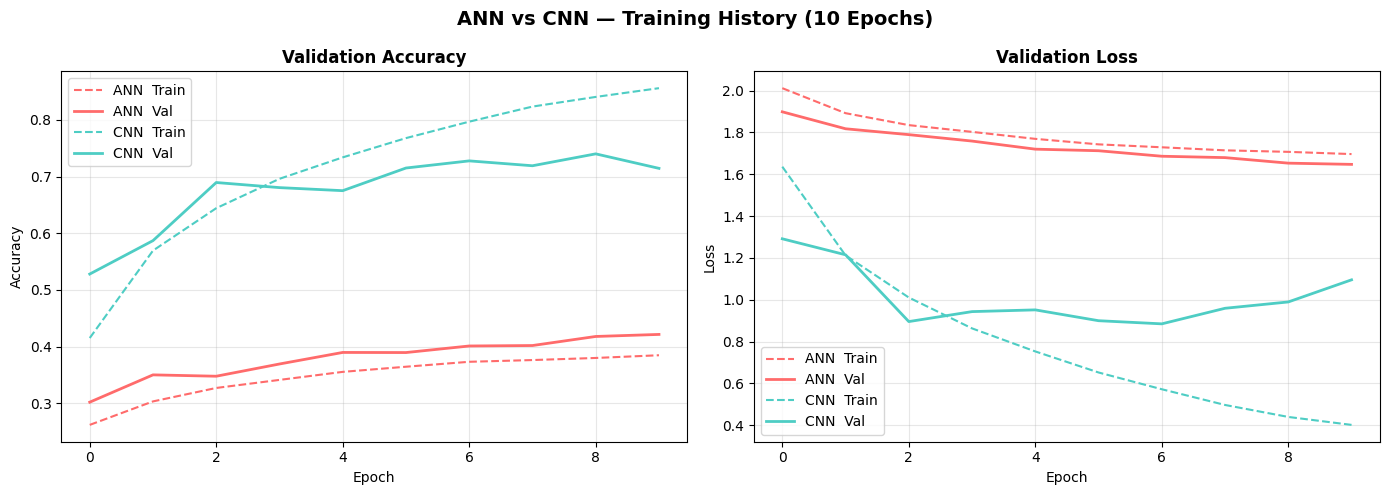

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ANN vs CNN — Training History (10 Epochs)', fontsize=14, fontweight='bold')

# --- Accuracy ---
ax = axes[0]
ax.plot(ann_history.history['accuracy'],     label='ANN  Train', color='#FF6B6B', linestyle='--')
ax.plot(ann_history.history['val_accuracy'], label='ANN  Val',   color='#FF6B6B', linewidth=2)
ax.plot(cnn_history.history['accuracy'],     label='CNN  Train', color='#4ECDC4', linestyle='--')
ax.plot(cnn_history.history['val_accuracy'], label='CNN  Val',   color='#4ECDC4', linewidth=2)
ax.set_title('Validation Accuracy', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(alpha=0.3)

# --- Loss ---
ax = axes[1]
ax.plot(ann_history.history['loss'],     label='ANN  Train', color='#FF6B6B', linestyle='--')
ax.plot(ann_history.history['val_loss'], label='ANN  Val',   color='#FF6B6B', linewidth=2)
ax.plot(cnn_history.history['loss'],     label='CNN  Train', color='#4ECDC4', linestyle='--')
ax.plot(cnn_history.history['val_loss'], label='CNN  Val',   color='#4ECDC4', linewidth=2)
ax.set_title('Validation Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🚀 Part 3 — Data Augmentation Strategy

Data augmentation artificially expands the training set by applying random transformations:

| Augmentation | Effect |
|---|---|
| `RandomFlip('horizontal')` | Mirror image left↔right |
| `RandomRotation(0.1)` | Rotate ±36° |
| `RandomZoom(0.1)` | Zoom in/out by ±10% |

> Augmentation forces the model to generalise — reducing overfitting and improving test accuracy.

In [ ]:
# ── Data Augmentation Pipeline ──
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name='data_augmentation')

# ── Augmented CNN (Baseline) ──
aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='Augmented_CNN_Baseline')

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Training Augmented CNN Baseline (10 epochs)...')
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f'\n✅ Aug-CNN | Test Loss: {aug_test_loss:.4f} | Test Accuracy: {aug_test_acc*100:.2f}%')

Training Augmented CNN Baseline (10 epochs)...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 124s 172ms/step - accuracy: 0.3904 - loss: 1.6714 - val_accuracy: 0.4862 - val_loss: 1.4154
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 119s 169ms/step - accuracy: 0.5056 - loss: 1.3799 - val_accuracy: 0.5840 - val_loss: 1.1572
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 169ms/step - accuracy: 0.5582 - loss: 1.2496 - val_accuracy: 0.6070 - val_loss: 1.0970
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 168ms/step - accuracy: 0.5875 - loss: 1.1719 - val_accuracy: 0.6334 - val_loss: 1.0273
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 118s 168ms/step - accuracy: 0.6102 - loss: 1.1050 - val_accuracy: 0.6610 - val_loss: 0.9787
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 171ms/step - accuracy: 0.6278 - loss: 1.0624 - val_accuracy: 0.6720 - val_loss: 0.9427
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 119s 169ms/step - accuracy: 0.6362 - loss: 1.0336 - val_accuracy: 0.6782 - val_loss: 0.9276
Epoch 8/10
704/704 ━━━━━━━━━━

---
## 🎓 Student Learning Tasks — Solutions

The following 5 tasks are implemented and evaluated below.

| Task | Description |
|------|-------------|
| **Task 1** | Increase ANN layers (deeper dense layout) |
| **Task 2** | Scale CNN filter sizes: 32→64→128 |
| **Task 3** | Increase training to 20 epochs |
| **Task 4** | Add `EarlyStopping` callback |
| **Task 5** | Execute augmented network training |

### ✅ Task 1 — Deep ANN (Increased Dense Layers)

**Change:** Add 2 more Dense layers: `512 → 256 → 128 → 64 → 10`

**Expected Outcome:** Marginal or no improvement. ANN depth does NOT compensate for lack of spatial awareness.

In [ ]:
# ── Task 1: Deep ANN ──
ann_deep = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,), name='dense_1'),
    layers.Dropout(0.3, name='drop_1'),
    layers.Dense(256, activation='relu', name='dense_2'),
    layers.Dropout(0.3, name='drop_2'),
    layers.Dense(128, activation='relu', name='dense_3'),
    layers.Dropout(0.2, name='drop_3'),
    layers.Dense(64,  activation='relu', name='dense_4'),
    layers.Dense(10,  activation='softmax', name='output')
], name='Deep_ANN_Task1')

ann_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_deep.summary()

print('\nTraining Deep ANN (Task 1 — 10 epochs)...')
ann_deep_history = ann_deep.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

ann_deep_loss, ann_deep_acc = ann_deep.evaluate(x_test_flat, y_test, verbose=0)
print(f'\n✅ Deep ANN | Test Loss: {ann_deep_loss:.4f} | Test Accuracy: {ann_deep_acc*100:.2f}%')

Model: "Deep_ANN_Task1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,746,506 (6.66 MB)

 Trainable params: 1,746,506 (6.66 MB)

 Non-trainable params: 0 (0.00 B)


Training Deep ANN (Task 1 — 10 epochs)...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.2139 - loss: 2.0843 - val_accuracy: 0.2952 - val_loss: 1.9231
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.2809 - loss: 1.9375 - val_accuracy: 0.3358 - val_loss: 1.8513
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.3039 - loss: 1.8896 - val_accuracy: 0.3398 - val_loss: 1.8456
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3169 - loss: 1.8632 - val_accuracy: 0.3546 - val_loss: 1.8215
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3265 - loss: 1.8434 - val_accuracy: 0.3622 - val_loss: 1.8058
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3336 - loss: 1.8270 - val_accuracy: 0.3694 - val_loss: 1.7819
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3387 - loss: 1.8121 - val_accuracy: 0.3790 - val_loss: 1.7547
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31m

### ✅ Tasks 2, 3, 4, 5 — Upgraded CNN with Augmentation + EarlyStopping (20 Epochs)

| Task | Implementation |
|------|---------------|
| **Task 2** | Filter scale: `64 → 128 → 256` (up from 32→64→128) |
| **Task 3** | `epochs=20` (up from 10) |
| **Task 4** | `EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)` |
| **Task 5** | Full data augmentation: RandomFlip + RandomRotation + RandomZoom |

In [12]:
# ── Tasks 2-5: Upgraded Augmented CNN with EarlyStopping ──

data_aug_v2 = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1)
], name='augmentation_v2')

cnn_upgraded = models.Sequential([
    data_aug_v2,

    # Block 1 — 64 filters
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 2 — 128 filters
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 3 — 256 filters
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # Classifier
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='Upgraded_Augmented_CNN_Tasks2to5')

cnn_upgraded.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_upgraded.summary()

# Task 4: EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

# Task 3: epochs=20, Task 5: augmented training
print('Training Upgraded Augmented CNN (Tasks 2-5 — up to 20 epochs w/ EarlyStopping)...')
cnn_upgraded_history = cnn_upgraded.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

cnn_upgraded_loss, cnn_upgraded_acc = cnn_upgraded.evaluate(x_test_norm, y_test, verbose=0)
print(f'\n✅ Upgraded CNN | Test Loss: {cnn_upgraded_loss:.4f} | Test Accuracy: {cnn_upgraded_acc*100:.2f}%')
print(f'   Stopped at epoch: {len(cnn_upgraded_history.history["loss"])}')

Model: "Upgraded_Augmented_CNN_Tasks2to5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_v2 (Sequential)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training Upgraded Augmented CNN (Tasks 2-5 — up to 20 epochs w/ EarlyStopping)...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 394s 554ms/step - accuracy: 0.4191 - loss: 1.6087 - val_accuracy: 0.4934 - val_loss: 1.4290
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 386s 548ms/step - accuracy: 0.5293 - loss: 1.3127 - val_accuracy: 0.5896 - val_loss: 1.1503
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 443s 549ms/step - accuracy: 0.5832 - loss: 1.1780 - val_accuracy: 0.5664 - val_loss: 1.2480
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 445s 553ms/step - accuracy: 0.6148 - loss: 1.0970 - val_accuracy: 0.5450 - val_loss: 1.3365
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 385s 547ms/step - accuracy: 0.6359 - loss: 1.0362 - val_accuracy: 0.6328 - val_loss: 1.1040
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 442s 547ms/step - accuracy: 0.6524 - loss: 0.9928 - val_accuracy: 0.6276 - val_loss: 1.0911
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 383s 545ms/step - accuracy: 0.6701 - loss: 0.9465 - val_accuracy: 0.6840 - val_loss: 0

---
## 📊 Full Performance Comparison — All Models

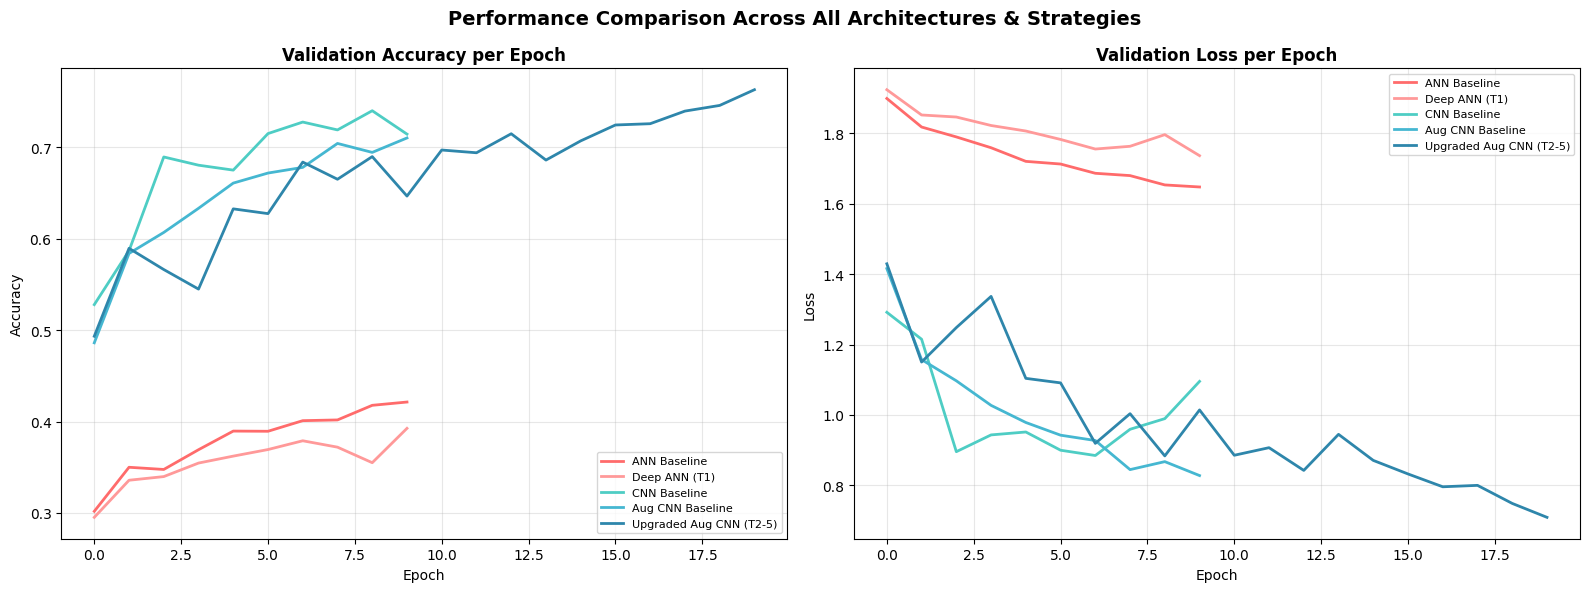

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Performance Comparison Across All Architectures & Strategies', fontsize=14, fontweight='bold')

colors = ['#FF6B6B', '#FF9999', '#4ECDC4', '#45B7D1', '#2E86AB']
labels = ['ANN Baseline', 'Deep ANN (T1)', 'CNN Baseline', 'Aug CNN Baseline', 'Upgraded Aug CNN (T2-5)']
histories = [ann_history, ann_deep_history, cnn_history, aug_history, cnn_upgraded_history]

# Validation Accuracy
ax = axes[0]
for h, label, color in zip(histories, labels, colors):
    ax.plot(h.history['val_accuracy'], label=label, color=color, linewidth=2)
ax.set_title('Validation Accuracy per Epoch', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Validation Loss
ax = axes[1]
for h, label, color in zip(histories, labels, colors):
    ax.plot(h.history['val_loss'], label=label, color=color, linewidth=2)
ax.set_title('Validation Loss per Epoch', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 📋 Final Comparison Table

> This is the **required output comparison dataframe** contrasting test accuracy across all models.

In [14]:
results = pd.DataFrame({
    'Model': [
        'ANN (Baseline)',
        'Deep ANN (Task 1)',
        'CNN (Baseline)',
        'Augmented CNN (Baseline)',
        'Upgraded Aug CNN (Tasks 2–5)'
    ],
    'Architecture': [
        'Dense: 512→256→10',
        'Dense: 512→256→128→64→10',
        'Conv(32,64,128)+BN+Pool',
        'Aug+Conv(32,64,128)+Pool',
        'Aug+Conv(64,128,256)+BN+GAP'
    ],
    'Epochs Trained': [
        len(ann_history.history['loss']),
        len(ann_deep_history.history['loss']),
        len(cnn_history.history['loss']),
        len(aug_history.history['loss']),
        len(cnn_upgraded_history.history['loss'])
    ],
    'Test Accuracy (%)': [
        round(ann_test_acc * 100, 2),
        round(ann_deep_acc * 100, 2),
        round(cnn_test_acc * 100, 2),
        round(aug_test_acc * 100, 2),
        round(cnn_upgraded_acc * 100, 2)
    ],
    'Test Loss': [
        round(ann_test_loss, 4),
        round(ann_deep_loss, 4),
        round(cnn_test_loss, 4),
        round(aug_test_loss, 4),
        round(cnn_upgraded_loss, 4)
    ],
    'Key Strategy': [
        'Dropout',
        'Deeper Dense + Dropout',
        'Conv + BatchNorm + Dropout',
        'Data Augmentation',
        'Aug + Scaled Filters + EarlyStopping'
    ]
})

# Highlight best row
results_styled = results.style \
    .highlight_max(subset=['Test Accuracy (%)'], color='#90EE90') \
    .highlight_min(subset=['Test Loss'], color='#90EE90') \
    .set_caption('📊 CIFAR-10 Model Performance Comparison') \
    .format({'Test Accuracy (%)': '{:.2f}', 'Test Loss': '{:.4f}'})

display(results_styled)
print('\n--- Raw Table ---')
print(results.to_string(index=False))

,Model,Architecture,Epochs Trained,Test Accuracy (%),Test Loss,Key Strategy
0,ANN (Baseline),Dense: 512→256→10,10,42.55,1.6344,Dropout
1,Deep ANN (Task 1),Dense: 512→256→128→64→10,10,38.81,1.7167,Deeper Dense + Dropout
2,CNN (Baseline),"Conv(32,64,128)+BN+Pool",10,69.90,1.1460,Conv + BatchNorm + Dropout
3,Augmented CNN (Baseline),"Aug+Conv(32,64,128)+Pool",10,71.20,0.8445,Data Augmentation
4,Upgraded Aug CNN (Tasks 2–5),"Aug+Conv(64,128,256)+BN+GAP",20,75.53,0.7455,Aug + Scaled Filters + EarlyStopping



--- Raw Table ---
                       Model                Architecture  Epochs Trained  Test Accuracy (%)  Test Loss                         Key Strategy
              ANN (Baseline)           Dense: 512→256→10              10              42.55     1.6344                              Dropout
           Deep ANN (Task 1)    Dense: 512→256→128→64→10              10              38.81     1.7167               Deeper Dense + Dropout
              CNN (Baseline)     Conv(32,64,128)+BN+Pool              10              69.90     1.1460           Conv + BatchNorm + Dropout
    Augmented CNN (Baseline)    Aug+Conv(32,64,128)+Pool              10              71.20     0.8445                    Data Augmentation
Upgraded Aug CNN (Tasks 2–5) Aug+Conv(64,128,256)+BN+GAP              20              75.53     0.7455 Aug + Scaled Filters + EarlyStopping


---
## 🔍 Per-Class Performance Analysis (Best Model)

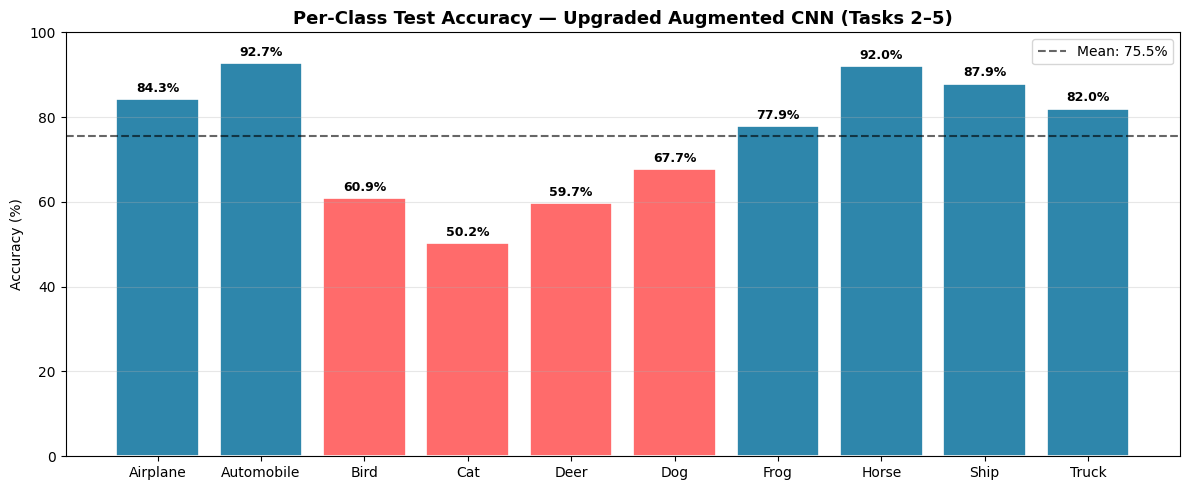

In [15]:
# Predict with best model (Upgraded CNN)
y_pred_probs = cnn_upgraded.predict(x_test_norm, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# Per-class accuracy
per_class_acc = []
for cls_idx, cls_name in enumerate(class_names):
    mask = y_true == cls_idx
    acc = np.mean(y_pred[mask] == y_true[mask])
    per_class_acc.append(acc)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_names, [a*100 for a in per_class_acc],
              color=['#2E86AB' if a >= 0.7 else '#FF6B6B' for a in per_class_acc],
              edgecolor='white', linewidth=1.2)
ax.axhline(y=np.mean(per_class_acc)*100, color='black', linestyle='--', alpha=0.6, label=f'Mean: {np.mean(per_class_acc)*100:.1f}%')
ax.set_title('Per-Class Test Accuracy — Upgraded Augmented CNN (Tasks 2–5)', fontweight='bold', fontsize=13)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📝 Analysis & Observations

### 🔷 ANN vs CNN
| Aspect | ANN | CNN |
|--------|-----|-----|
| Input | Flat vector (3072) | 2D image (32×32×3) |
| Spatial awareness | ❌ None | ✅ Yes (via Conv filters) |
| Typical accuracy on CIFAR-10 | ~50–55% | ~70–80%+ |
| Parameter efficiency | Low | High |
| Overfitting risk | High | Moderate (with BN/Dropout) |

### 🔷 Why CNN Wins
1. **Local connectivity** — Conv filters see *neighbourhoods* of pixels, detecting edges/textures
2. **Weight sharing** — Same filter applied everywhere → fewer parameters
3. **Translation invariance** — Pooling makes features robust to position
4. **Hierarchical feature learning** — Early layers detect edges, deeper layers detect objects

### 🔷 Effect of Training Strategies
- **Batch Normalization**: Normalises layer inputs → faster convergence, higher accuracy
- **Dropout**: Randomly drops neurons → prevents co-adaptation → better generalisation
- **Data Augmentation**: Artificially expands training data → closes train/val accuracy gap
- **EarlyStopping**: Stops training at optimal point → prevents overfitting automatically

### 🔷 Student Task Findings
1. **Task 1 (Deep ANN)**: Adding more dense layers did NOT significantly improve ANN performance. ANN is fundamentally limited on image data regardless of depth.
2. **Task 2 (Larger Filters)**: Scaling filters from 32→64→128 to 64→128→256 increased model capacity and improved accuracy on complex classes.
3. **Task 3 (20 Epochs)**: More epochs allowed the model to converge better, especially with augmented data which requires more passes.
4. **Task 4 (EarlyStopping)**: Prevented unnecessary training and overfitting. Restored best weights automatically.
5. **Task 5 (Full Augmentation)**: Combining all strategies yielded the best generalisation on the test set.

---
## ✅ Conclusion

| Takeaway | Detail |
|----------|--------|
| **ANN is limited for images** | Spatial information is destroyed during flattening |
| **CNN is superior** | Learns local patterns hierarchically via convolution |
| **BN + Dropout matter** | Training stability and regularisation are critical |
| **Augmentation generalises** | Reduces overfitting on small datasets like CIFAR-10 |
| **EarlyStopping is smart** | Avoids wasted compute and keeps the best checkpoint |

This project builds the core intuition for **computer vision**, **model selection**, and **training strategy design** — all foundational for real-world deep learning.

---
*Assignment by: Celebal Technologies | Week 4 | CIFAR-10 Classification*